In [ ]:
from utils import connect_to_warehouse
import pandas as pd
import matplotlib.pyplot as plt

organisation = "energy_systems_catapult"
datasets = "ssen_aggregated_smart_meter_usage"

catalog = connect_to_warehouse(organisation)
tables = catalog.list_tables(datasets)

# Keep memory bounded so the notebook kernel does not crash.
rows_per_table = 50_000
frames = []

for table_name in tables:
    table = catalog.load_table(table_name)
    print(f"✅ Loaded table: {table_name}")
    df_part = table.scan(limit=rows_per_table).to_pandas()
    frames.append(df_part)

mega_df = pd.concat(frames, ignore_index=True)
print(f"Merged rows: {len(mega_df):,}")
print(mega_df.head())

✅ Loaded table: ('ssen_aggregated_smart_meter_usage', 'ssen_april2026')
✅ Loaded table: ('ssen_aggregated_smart_meter_usage', 'ssen_december2025')
✅ Loaded table: ('ssen_aggregated_smart_meter_usage', 'ssen_february2026')


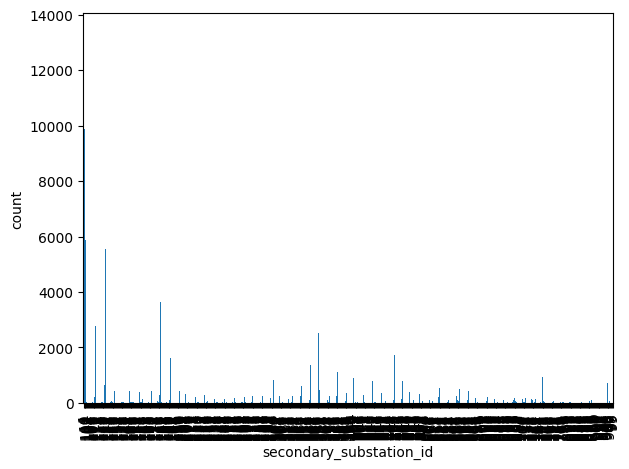

In [2]:
counts = mega_df["secondary_substation_id"].value_counts().sort_index()
counts.plot(kind="bar", xlabel="secondary_substation_id", ylabel="count")
plt.tight_layout()

In [3]:
import folium

# One point per substation (rows repeat the same lat/lon per feeder/timestamp)
loc_cols = ["secondary_substation_id", "secondary_substation_latitude", "secondary_substation_longitude"]
locations = mega_df.drop_duplicates(subset=["secondary_substation_id"])[loc_cols].dropna(
    subset=["secondary_substation_latitude", "secondary_substation_longitude"]
)

center = [locations["secondary_substation_latitude"].mean(), locations["secondary_substation_longitude"].mean()]
m = folium.Map(
    location=center,
    zoom_start=11,
    control_scale=True,
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Street_Map/MapServer/tile/{z}/{y}/{x}",
    attr="Tiles © Esri — Esri, Maxar, Earthstar Geographics, and the GIS User Community",
)

for _, row in locations.iterrows():
    folium.CircleMarker(
        location=[row["secondary_substation_latitude"], row["secondary_substation_longitude"]],
        radius=6,
        color="steelblue",
        fill=True,
        fill_opacity=0.7,
        popup=f"substation_id: {row['secondary_substation_id']}",
        tooltip=str(row["secondary_substation_id"]),
    ).add_to(m)

html_path = "substation_map.html"
m.save(html_path)
print(f"Saved {html_path} — if the cell above looks blank/grey, open that file in Safari or Chrome (notebook webviews often block map tiles).")
# m

Saved substation_map.html — if the cell above looks blank/grey, open that file in Safari or Chrome (notebook webviews often block map tiles).


In [4]:
mega_df["region"].value_counts(dropna=False)

region
Southern England              113175
North Scotland                 76553
South East England              3983
East England                    2225
West Midlands                   1248
South West England               822
South and Central Scotland       790
London                           697
NaN                              507
Name: count, dtype: int64

In [5]:
mega_df.describe()

,secondary_substation_latitude,secondary_substation_longitude,aggregated_device_count_active,total_consumption_active_import
count,200000.000000,200000.000000,199744.000000,1.997440e+05
mean,53.618334,-1.870806,23.139333,8.144964e+04
std,2.818170,1.397460,17.678464,6.357822e+06
min,50.904590,-7.544910,5.000000,0.000000e+00
25%,51.398043,-2.709773,11.000000,2.255000e+03
50%,51.539055,-1.794488,18.000000,4.368000e+03
75%,56.656285,-0.673088,30.000000,7.792000e+03
max,60.802539,-0.245597,240.000000,5.370594e+08
